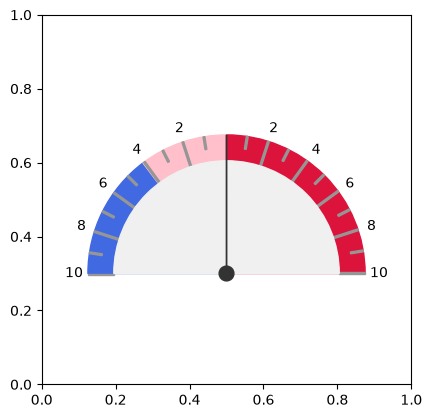

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Arc, Wedge, Rectangle
import matplotlib.text as mtext

import pandas as pd
import numpy as np


fig, ax = plt.subplots()

slices = pd.DataFrame([[-10.0, 'royalblue'], [-4.12, 'Pink'], [0.0, 'crimson']], columns=['Start markers', 'Color'])
slices['End markers'] = slices['Start markers'].tolist()[1:] + [10]
min = slices['Start markers'].min()
max = slices['End markers'].max()
sidelen = np.abs([min, max]).max()
if sidelen % 5 != 0:
    sidelen = 5 * (sidelen // 5) + 5
min = -sidelen
max = sidelen
total = max - min
slices['Proportion'] = np.abs(slices['End markers'] - slices['Start markers']) / total

fulcrum = (0.5, 0.3)
r = 3 / 8

upto_part = 0
for _, slice in slices.iterrows():
    theta1 = upto_part * 180
    theta2 = theta1 + (slice['Proportion'] * 180)
    wd = Wedge(fulcrum, r=r, theta1=180 - theta2, theta2=180 - theta1, color=slice['Color'])
    ax.add_patch(wd)
    upto_part += slice['Proportion']

inc = int(sidelen / 5)
markw = 0.07
for i in range(1, 11, 1):
    height = markw if i % 2 == 0 else markw / 2
    ang_p = (i / sidelen * (np.pi / 2))
    angle1 = (np.pi / 2) - ang_p
    angle2 = (np.pi / 2) + ang_p
    def draw(angle):
        (x, y) = fulcrum
        x1 = x + (np.cos(angle) * r)
        y1 = y + (np.sin(angle) * r)
        mark = Rectangle((x1, y1), width=0.005, height=height, angle=np.degrees(angle) + 90,
                         color='#969696')
        ax.add_patch(mark)

        if i % 2 == 0:
            x2 = x + (np.cos(angle) * r * 1.1)
            y2 = y + (np.sin(angle) * r * 1.1)
            ax.text(x2, y2, s=i, horizontalalignment='center', verticalalignment='center')

    draw(angle1)
    draw(angle2)

mid = Wedge(fulcrum, r=r - markw, theta1=0, theta2=180, color='#f0f0f0')
ax.add_patch(mid)

fu_r = 0.02
fu_color = '#333333'
swing = 0
angle = -(swing / sidelen * (np.pi / 2)) + (np.pi / 2)

fu = Circle(fulcrum, radius=fu_r, color=fu_color)
ax.add_patch(fu)

theta1 = -np.arctan(fu_r) + np.degrees(angle) + 180
theta2 = np.arctan(fu_r) + np.degrees(angle) + 180
pnt = Wedge((np.cos(angle) * r + fulcrum[0], 
             np.sin(angle) * r + fulcrum[1]), 
             r=r, theta1=theta1, theta2=theta2, color=fu_color)
ax.add_patch(pnt)

ax.set_aspect('equal')
plt.show()